# Heart Disease Dataset - Preprocessing

In this notebook, we prepare the Heart Disease Cleveland dataset before applying classification models.

The preprocessing includes:
- loading and inspecting the dataset
- checking missing values and duplicates
- exploring basic distributions
- reviewing correlations
- applying one-hot encoding to categorical variables
- splitting the data into training and testing sets
- preparing raw data for Decision Tree
- preparing scaled data for BPN

## 1. Load Libraries
In this section, the required libraries are imported.

- pandas is used for handling tabular data
- matplotlib and seaborn are used for visualization
- train_test_split is used to divide the dataset into training and testing sets
- StandardScaler is used later to scale the features for the neural network

In [1]:
# Import pandas for data manipulation
import pandas as pd

# Import matplotlib for data visualization
import matplotlib.pyplot as plt

# Import seaborn for statistical plots
import seaborn as sns

# Import train_test_split to divide the dataset
from sklearn.model_selection import train_test_split

# Import StandardScaler to normalize the features for BPN
from sklearn.preprocessing import StandardScaler

## 2. Load Dataset
The dataset is loaded from a CSV file and stored in a DataFrame called `df`.

The `head()` function is used to display the first rows and verify that the file was loaded correctly.

In [2]:
import pandas as pd

# Cargar dataset
df = pd.read_csv("Heart_disease_cleveland_new.csv") 
# Ver primeras filas
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


## 3. Initial Review
This section provides a first overview of the dataset.

- `shape` shows the number of rows and columns
- `columns` shows all feature names
- `info()` displays data types and confirms whether the dataset is already numeric

In [3]:
# Print the shape of the dataset
print("Dataset shape:", df.shape)

# Print the list of column names
print("Columns:", df.columns.tolist())

# Show dataset structure and data types
df.info()

Dataset shape: (303, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


## 4. Statistical Summary

This section provides descriptive statistics such as:

- mean
- standard deviation
- minimum and maximum values
- quartiles

It helps us understand the general scale and distribution of the variables.

In [4]:
# Show statistical summary for numerical columns
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


## 5. Missing Values and Duplicates

Before training a model, it is important to verify whether the dataset contains:

- missing values
- duplicated rows

In this dataset, these checks help confirm whether additional cleaning is necessary.

In [5]:
# Check missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

# Check duplicated rows
print("\nNumber of duplicated rows:", df.duplicated().sum())

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Number of duplicated rows: 0


## 6. Target Distribution

This section shows how many samples belong to each target class.

This is important because class imbalance can affect model performance.

Target distribution:
target
0    164
1    139
Name: count, dtype: int64


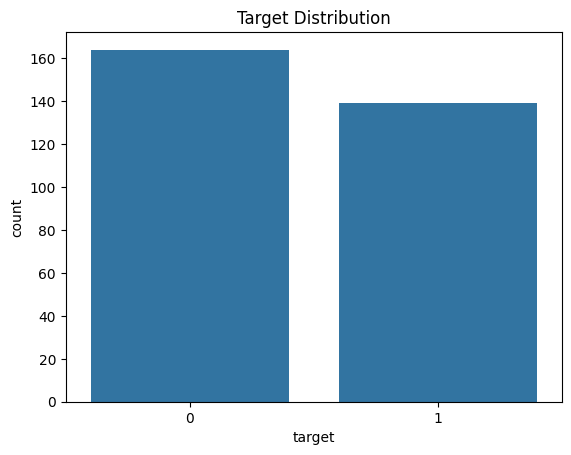

In [6]:
# Show the distribution of the target variable
print("Target distribution:")
print(df["target"].value_counts())

# Plot the target distribution
sns.countplot(x="target", data=df)
plt.title("Target Distribution")
plt.show()

## 7. Histograms of Variables
### Variable Distributions
Histograms are used to visualize the distribution of each variable.

This helps identify:
- skewed distributions
- unusual ranges
- possible outliers
- general feature behavior

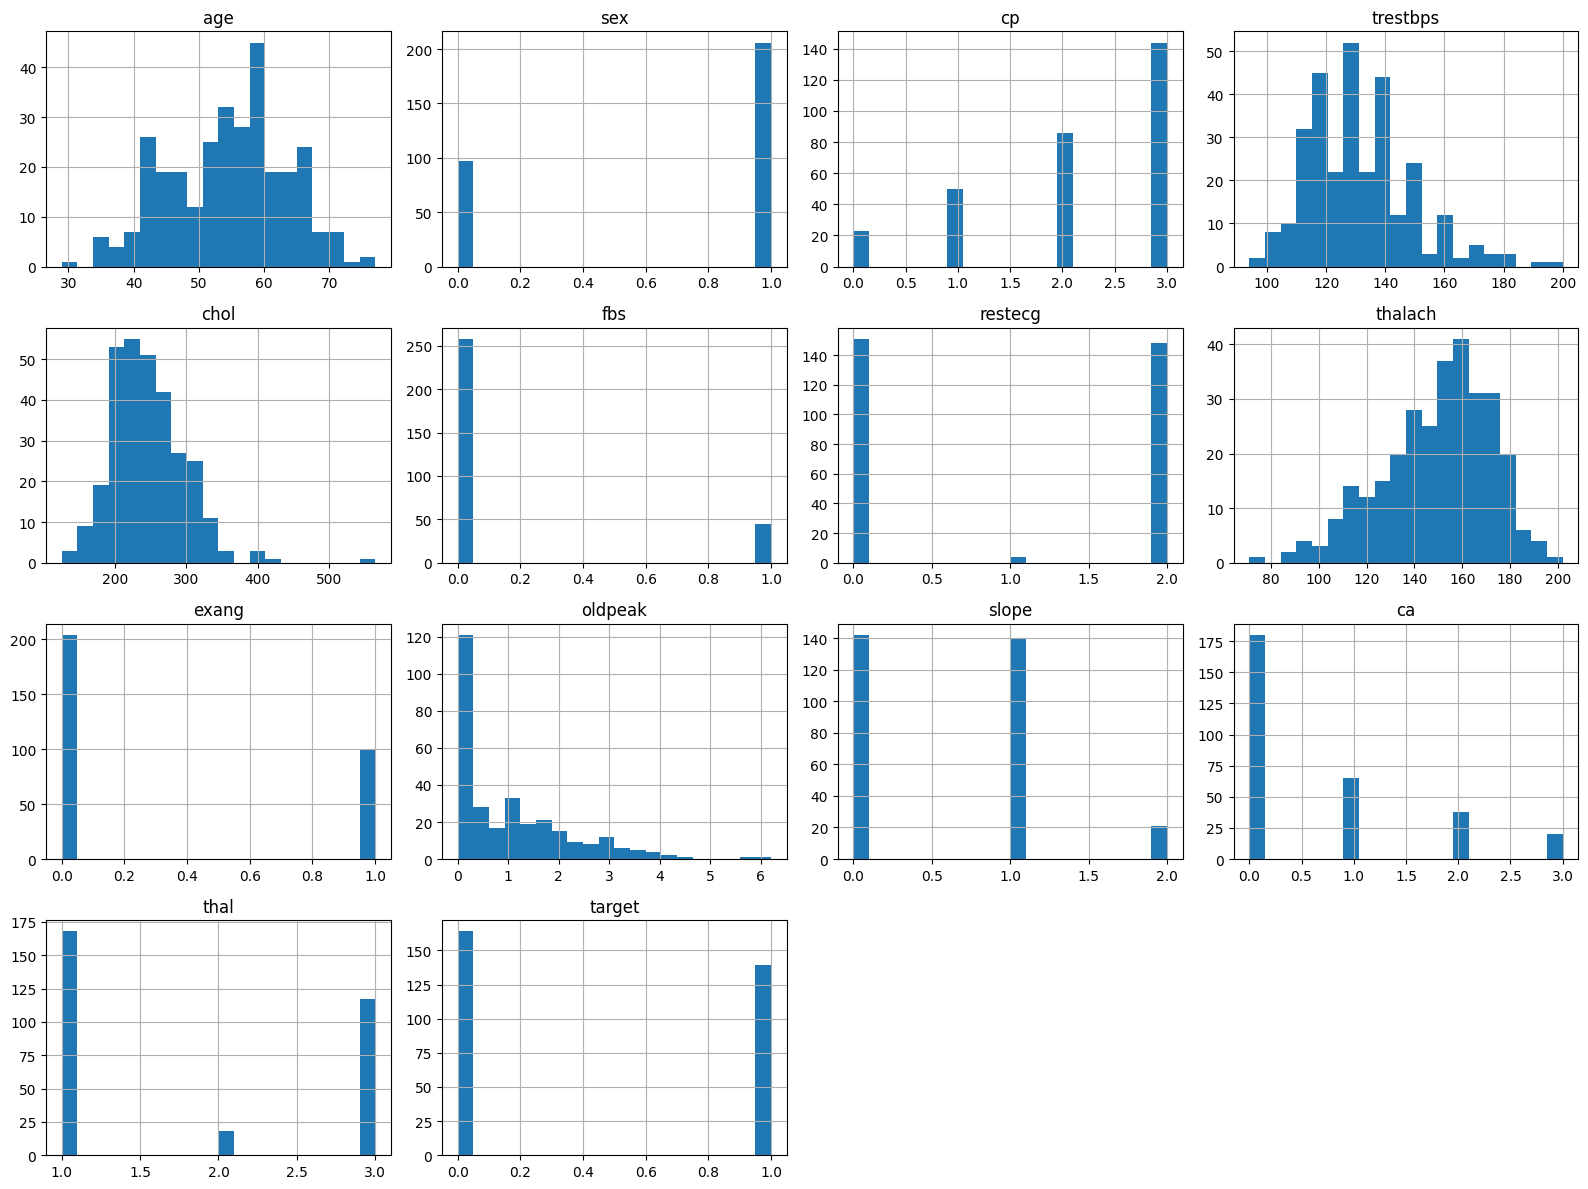

In [7]:
# Plot histograms for all variables
df.hist(bins=20, figsize=(16, 12))
plt.tight_layout()
plt.show()

## 8. Boxplots for Outlier Inspection
## Outlier Inspection

Boxplots are used to visually inspect possible outliers.

In medical datasets, extreme values are not always errors, so outliers should be interpreted carefully.

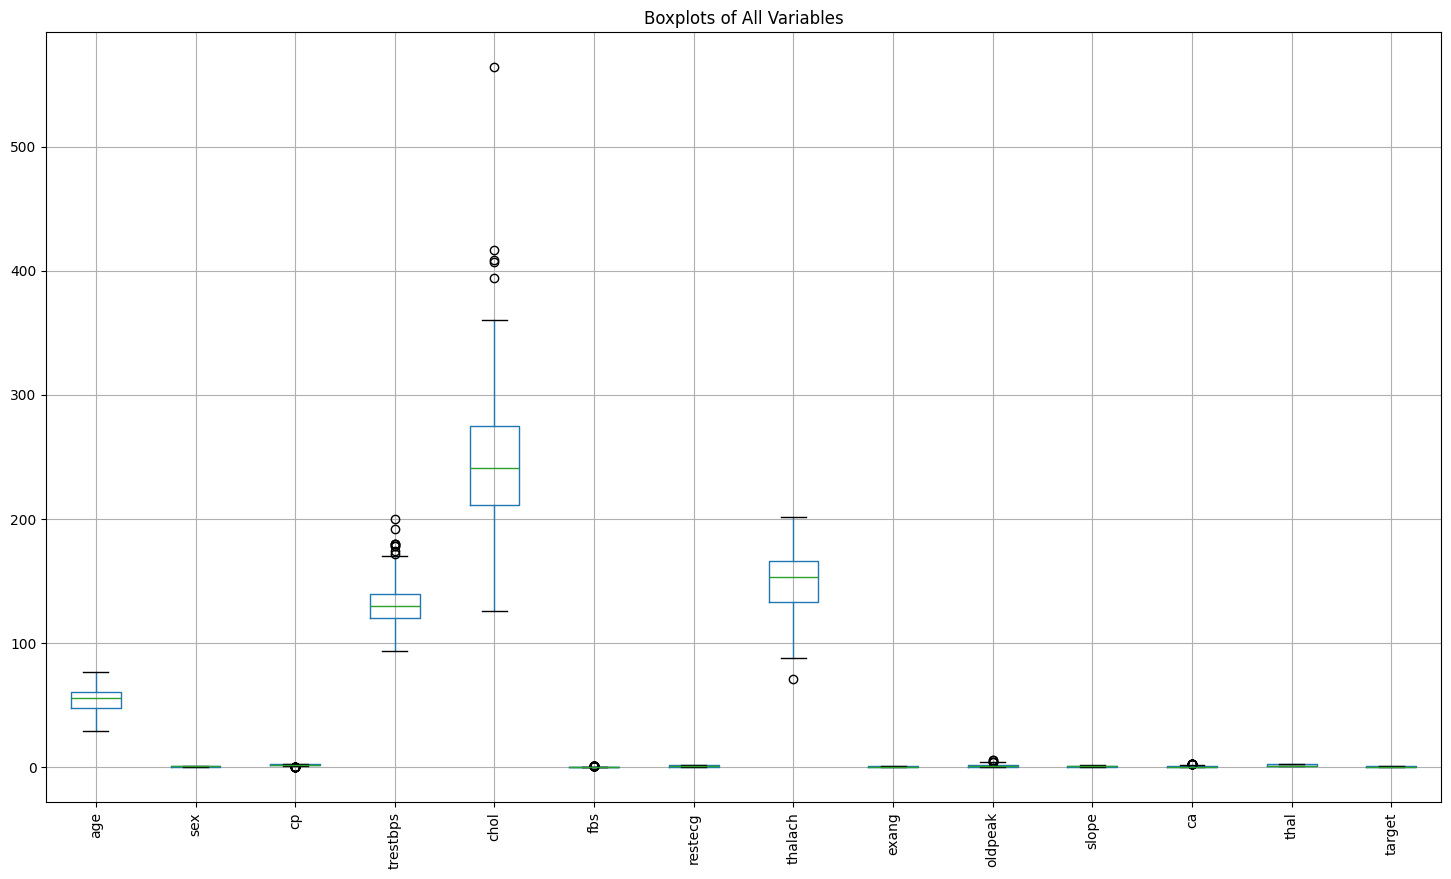

In [8]:
# Create boxplots for all columns
plt.figure(figsize=(18, 10))
df.boxplot(rot=90)
plt.title("Boxplots of All Variables")
plt.show()

## 9. Correlation Heatmap Analysis
The correlation heatmap helps identify relationships between variables.

It can be useful for:
- detecting highly related features
- understanding which variables may be more related to the target
- exploring possible redundancy in the dataset

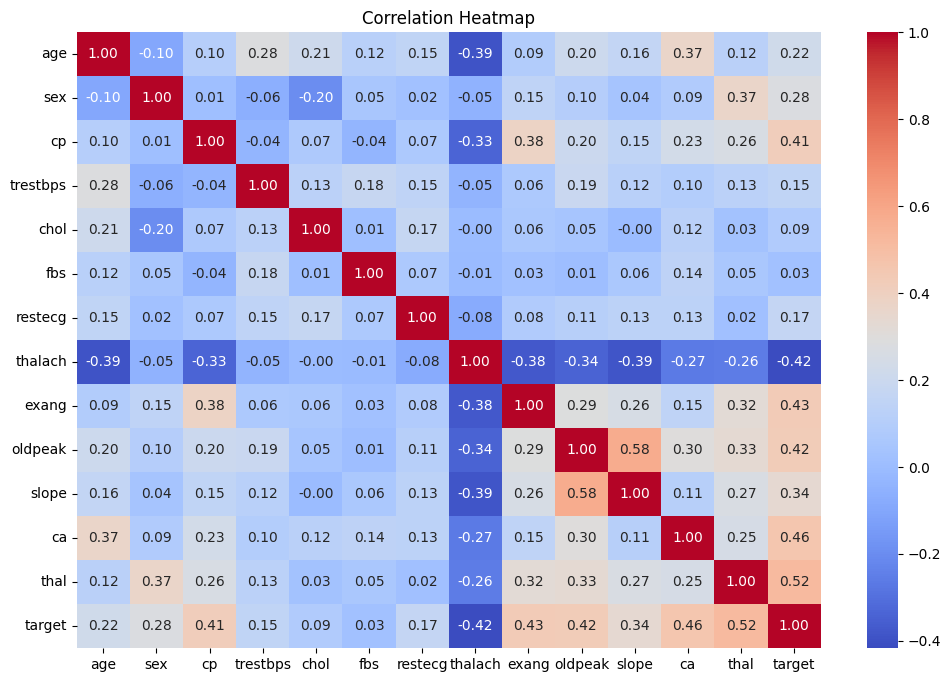

In [9]:
# Compute the correlation matrix
corr_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 10. One-Hot Encoding

Some variables in the Heart Disease dataset are categorical, even though they are stored as numbers.

Examples include:
- chest pain type (`cp`)
- resting electrocardiographic results (`restecg`)
- slope of the peak exercise ST segment (`slope`)
- thalassemia (`thal`)

If these variables are left as plain integers, the model may incorrectly assume that they have a natural ordinal relationship.

To avoid this problem, one-hot encoding is applied. This converts each category into separate binary columns.

This step is especially important for the BPN model, but it also improves the consistency of the overall preprocessing pipeline.

In [10]:
# Define the categorical columns that should be one-hot encoded
categorical_cols = ["cp", "restecg", "slope", "thal"]

# Apply one-hot encoding to categorical variables
# drop_first=True avoids redundant dummy columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the first rows after encoding
df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_2,thal_3
0,63,1,145,233,1,150,0,2.3,0,0,False,False,False,False,True,False,True,True,False
1,67,1,160,286,0,108,1,1.5,3,1,False,False,True,False,True,True,False,False,False
2,67,1,120,229,0,129,1,2.6,2,1,False,False,True,False,True,True,False,False,True
3,37,1,130,250,0,187,0,3.5,0,0,False,True,False,False,False,False,True,False,False
4,41,0,130,204,0,172,0,1.4,0,0,True,False,False,False,True,False,False,False,False


## 11. Define Features and Target

After one-hot encoding, the dataset is separated into:

- `X`: input features
- `y`: target variable

At this stage, the number of feature columns increases because categorical variables have been expanded into binary dummy variables.

In [11]:
# Separate input features from the target variable
X = df.drop("target", axis=1)

# Define the target variable
y = df["target"]

# Print feature matrix shape
print("X shape:", X.shape)

# Print target vector shape
print("y shape:", y.shape)

# Show the final feature names after encoding
print("Feature columns:")
print(X.columns.tolist())

X shape: (303, 18)
y shape: (303,)
Feature columns:
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2', 'slope_1', 'slope_2', 'thal_2', 'thal_3']


## 11. Train-Test Split

The dataset is divided into training and testing sets.

- The training set is used to train the models
- The testing set is used to evaluate model performance on unseen data

Stratified splitting is used to preserve the target class distribution in both subsets.

In [12]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Print shapes of the split datasets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (212, 18)
X_test shape: (91, 18)
y_train shape: (212,)
y_test shape: (91,)


## 12. Raw Data for Decision Tree

Decision Tree does not require feature scaling.

This is because tree-based models split data using threshold rules instead of distances.

For that reason, we keep a raw version of the training and testing data for the Decision Tree model.

In [13]:
# Keep a raw copy of the training and testing data for Decision Tree
X_train_raw = X_train.copy()
X_test_raw = X_test.copy()

## 13. Scaled Data for BPN

Backpropagation Neural Networks are sensitive to the scale of the input variables.

For this reason, the feature values are standardized using `StandardScaler`.

Important:
- `fit_transform()` is applied only on the training set
- `transform()` is applied on the test set

This prevents data leakage.

In [14]:
# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data using the same scaler
X_test_scaled = scaler.transform(X_test)

## 14. Final Check

At this stage, the preprocessing is complete.

Two versions of the dataset are ready:

- raw data for Decision Tree
- scaled data for BPN

Both models will use the same target labels (`y_train` and `y_test`) to ensure a fair comparison.

In [15]:
# Print final shapes of all prepared datasets
print("Raw training set shape for Decision Tree:", X_train_raw.shape)
print("Raw testing set shape for Decision Tree:", X_test_raw.shape)
print("Scaled training set shape for BPN:", X_train_scaled.shape)
print("Scaled testing set shape for BPN:", X_test_scaled.shape)

Raw training set shape for Decision Tree: (212, 18)
Raw testing set shape for Decision Tree: (91, 18)
Scaled training set shape for BPN: (212, 18)
Scaled testing set shape for BPN: (91, 18)


## 15. Optional Export

If needed, the processed datasets can be saved for reuse in other notebooks.

This allows both team members to access the same train-test split while using the version appropriate for each model.

In [16]:
# Optional: save cleaned raw train and test sets
X_train_raw.to_csv("X_train_raw.csv", index=False)
X_test_raw.to_csv("X_test_raw.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

# Optional: convert scaled arrays to DataFrames before saving
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Save scaled train and test sets
X_train_scaled_df.to_csv("X_train_scaled.csv", index=False)
X_test_scaled_df.to_csv("X_test_scaled.csv", index=False)